# End-to-End Machine Learning Pipeline on Tesla Sales Data

## Objective

This project performs data preprocessing, exploratory data analysis (EDA), feature engineering, regression modeling, hyperparameter tuning, and time series forecasting using Tesla deliveries data.

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings("ignore")

Load dataset

In [11]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


Data understanding :

In [12]:
print("Shape:", df.shape)

df.info()

df.describe()

df.isnull().sum()

Shape: (2640, 12)
<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 247.6 KB


Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Data cleaning :


# EDA (exploratory data analysis)

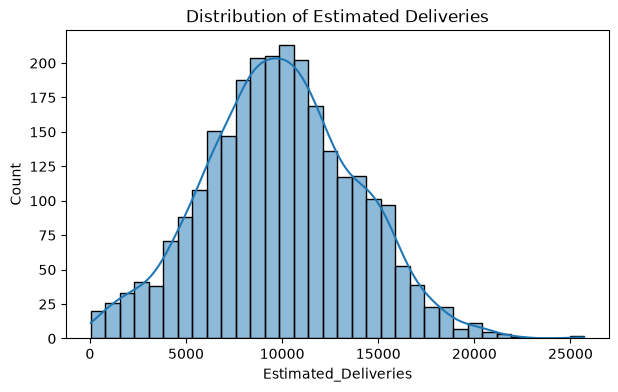

In [13]:
plt.figure(figsize=(7,4))
sns.histplot(df["Estimated_Deliveries"], kde=True)
plt.title("Distribution of Estimated Deliveries")
plt.show()

obeservation : Most delivery values are concentrated in a specific range.

correlation heat map :


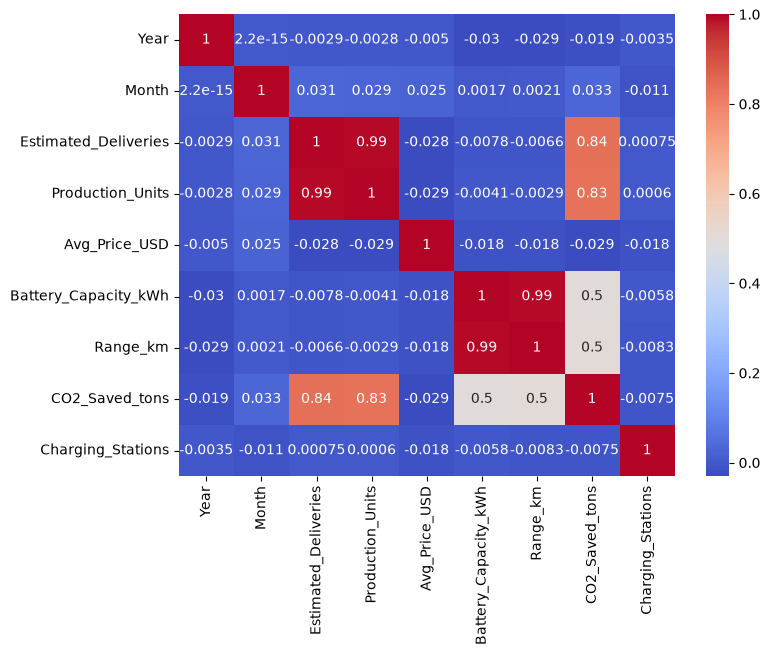

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap="coolwarm")
plt.show()

Observation:

Production units have a positive relationship with estimated deliveries

Deliveries by Year

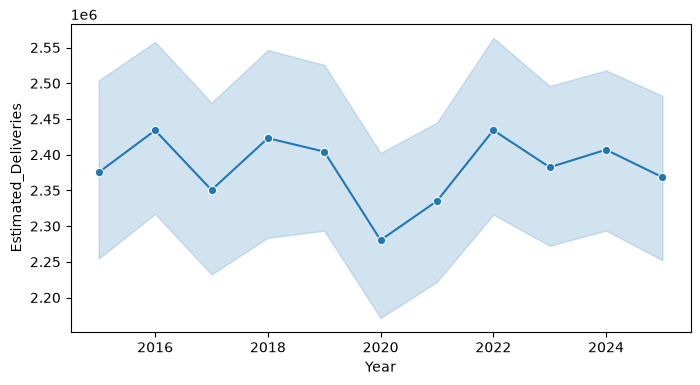

In [15]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df,
             x="Year",
             y="Estimated_Deliveries",
             estimator="sum",
             marker="o")
plt.show()

Observation:

Deliveries generally increase over time.

Deliveries by Region

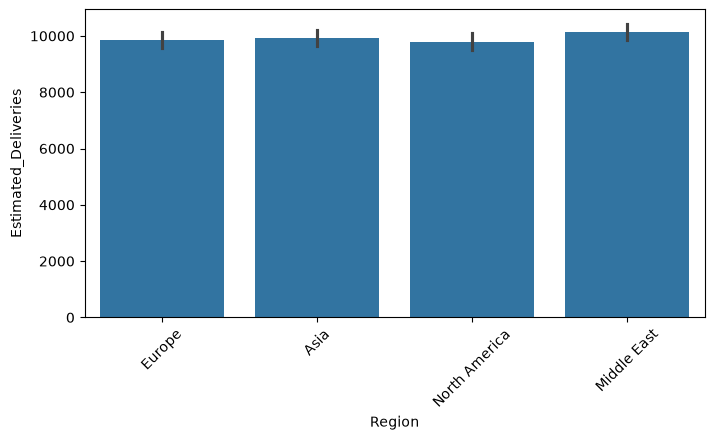

In [16]:
plt.figure(figsize=(8,4))
sns.barplot(data=df,
            x="Region",
            y="Estimated_Deliveries")

plt.xticks(rotation=45)
plt.show()

Observation:

Some regions contribute more to vehicle deliveries than others.

Production vs Deliveries

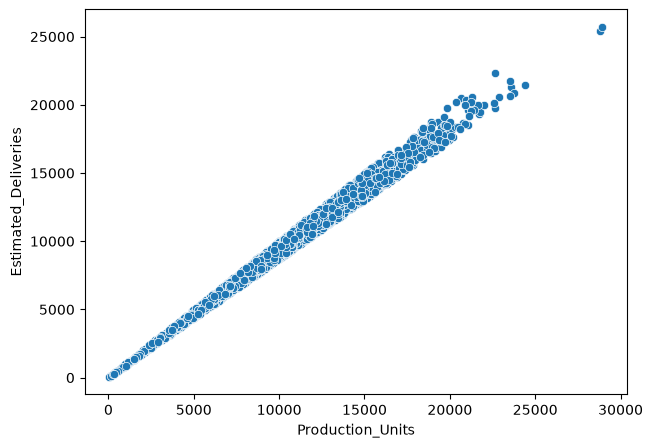

In [17]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df,
                x="Production_Units",
                y="Estimated_Deliveries")
plt.show()

Observation:

Production and deliveries show a positive relationship.

## Feature Engineering

In [18]:
df["Quarter"] = ((df["Month"]-1)//3)+1

Label Encoding

In [19]:
encoder = LabelEncoder()

for col in ["Region","Model","Source_Type"]:
    df[col] = encoder.fit_transform(df[col])

Train Test Split

In [23]:
# Select input features

X = df[
    [
        "Year",
        "Month",
        "Region",
        "Model",
        "Production_Units",
        "Avg_Price_USD",
        "Battery_Capacity_kWh",
        "Range_km",
        "CO2_Saved_tons",
        "Source_Type",
        "Charging_Stations",
        "Quarter"
    ]
]

# Target variable
y = df["Estimated_Deliveries"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (2112, 12)
Testing Shape: (528, 12)


## Linear Regression

A Linear Regression model is trained to predict the estimated deliveries.

In [24]:
# Train Linear Regression model

lr = LinearRegression()

lr.fit(X_train, y_train)

# Predictions
lr_pred = lr.predict(X_test)

# Evaluation
print("Linear Regression Performance")
print("MAE :", mean_absolute_error(y_test, lr_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score :", r2_score(y_test, lr_pred))

Linear Regression Performance
MAE : 309.99830928548886
RMSE : 383.46787089712456
R2 Score : 0.9901351961876608


## Random Forest Regressor

Random Forest is used to improve prediction accuracy by combining multiple decision trees.

In [25]:
# Train Random Forest model

rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

# Predictions
rf_pred = rf.predict(X_test)

# Evaluation
print("Random Forest Performance")
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score :", r2_score(y_test, rf_pred))

Random Forest Performance
MAE : 323.2826136363636
RMSE : 408.23470255442146
R2 Score : 0.9888197805601558


## Hyperparameter Tuning

GridSearchCV is used to find the best parameters for the Random Forest model.

In [26]:
# Hyperparameter tuning

params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=3
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': 10, 'n_estimators': 200}


# Best model

best_model = grid.best_estimator_

best_pred = best_model.predict(X_test)

print("Tuned Random Forest Performance")
print("MAE :", mean_absolute_error(y_test, best_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, best_pred)))
print("R2 Score :", r2_score(y_test, best_pred))

In [27]:
# Best model

best_model = grid.best_estimator_

best_pred = best_model.predict(X_test)

print("Tuned Random Forest Performance")
print("MAE :", mean_absolute_error(y_test, best_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, best_pred)))
print("R2 Score :", r2_score(y_test, best_pred))

Tuned Random Forest Performance
MAE : 325.7802877501827
RMSE : 411.3493047523713
R2 Score : 0.988648532149576


## Model Comparison

In [28]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, best_pred)
    ]
})

comparison

,Model,R2 Score
0,Linear Regression,0.990135
1,Random Forest,0.988820
2,Tuned Random Forest,0.988649


## Time Series Forecasting

The ARIMA model is used to forecast future estimated deliveries based on yearly delivery trends.

In [30]:
# Aggregate deliveries by Year

ts = df.groupby("Year")["Estimated_Deliveries"].sum()

ts

Year
2015    2375267
2016    2434081
2017    2350517
2018    2423104
2019    2404230
2020    2280336
2021    2335116
2022    2434220
2023    2382375
2024    2406899
2025    2368462
Name: Estimated_Deliveries, dtype: int64

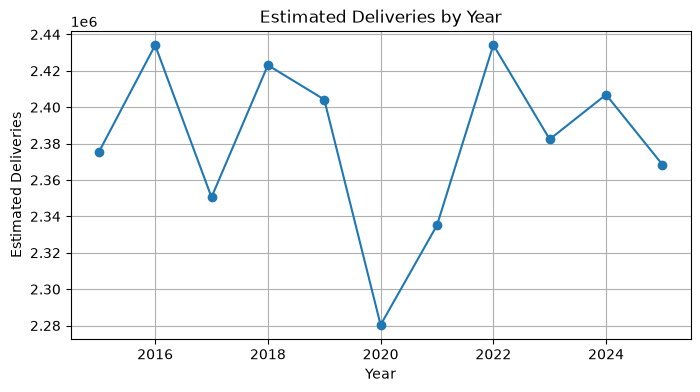

In [31]:
# Plot yearly deliveries

plt.figure(figsize=(8,4))

plt.plot(ts.index, ts.values, marker='o')

plt.title("Estimated Deliveries by Year")

plt.xlabel("Year")

plt.ylabel("Estimated Deliveries")

plt.grid(True)

plt.show()

In [32]:
# Train ARIMA model

model = ARIMA(ts, order=(1,1,1))

model_fit = model.fit()

In [33]:
# Forecast next 3 years

forecast = model_fit.forecast(steps=3)

print(forecast)

11    2.366761e+06
12    2.367844e+06
13    2.367155e+06
Name: predicted_mean, dtype: float64


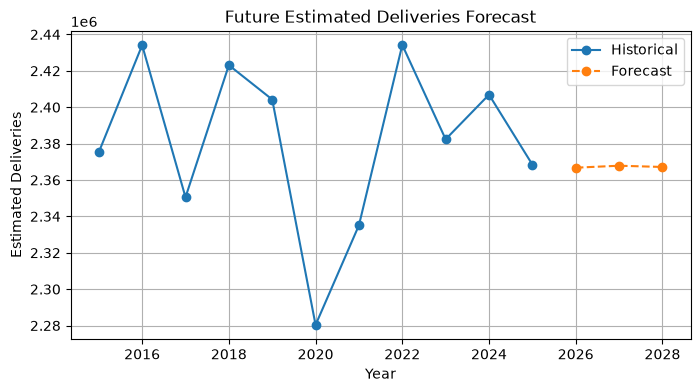

In [34]:
# Plot Forecast

future_years = [ts.index.max()+1,
                ts.index.max()+2,
                ts.index.max()+3]

plt.figure(figsize=(8,4))

plt.plot(ts.index, ts.values,
         marker='o',
         label="Historical")

plt.plot(future_years,
         forecast,
         marker='o',
         linestyle='--',
         label="Forecast")

plt.title("Future Estimated Deliveries Forecast")

plt.xlabel("Year")

plt.ylabel("Estimated Deliveries")

plt.legend()

plt.grid(True)

plt.show()

# Conclusion

- The dataset was successfully preprocessed and analyzed.
- Feature engineering was performed by creating a Quarter feature.
- Linear Regression and Random Forest models were trained for prediction.
- GridSearchCV was used to improve the Random Forest model.
- ARIMA was used for forecasting future estimated deliveries.